# Visualization

Plots to tell the story: **BTC and GPU price** over time, **value (perf-per-dollar)**, and **GPU supply chain** (TSMC, NVIDIA, AMD, Micron) vs GPU price. Uses `merged_yearly.csv` from the correlation notebook. Supply chain series help show whether fab, designers, and memory suppliers move with median GPU price.

## Load

In [15]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA_PROC = ROOT / "data" / "processed"
sns.set_style("whitegrid")

In [16]:
df = pd.read_csv(DATA_PROC / "merged_yearly.csv").dropna(subset=["median_gpu_price", "btc_avg_price", "median_perf_per_dollar"])
df = df.sort_values("year")

## BTC vs median GPU price (time series)

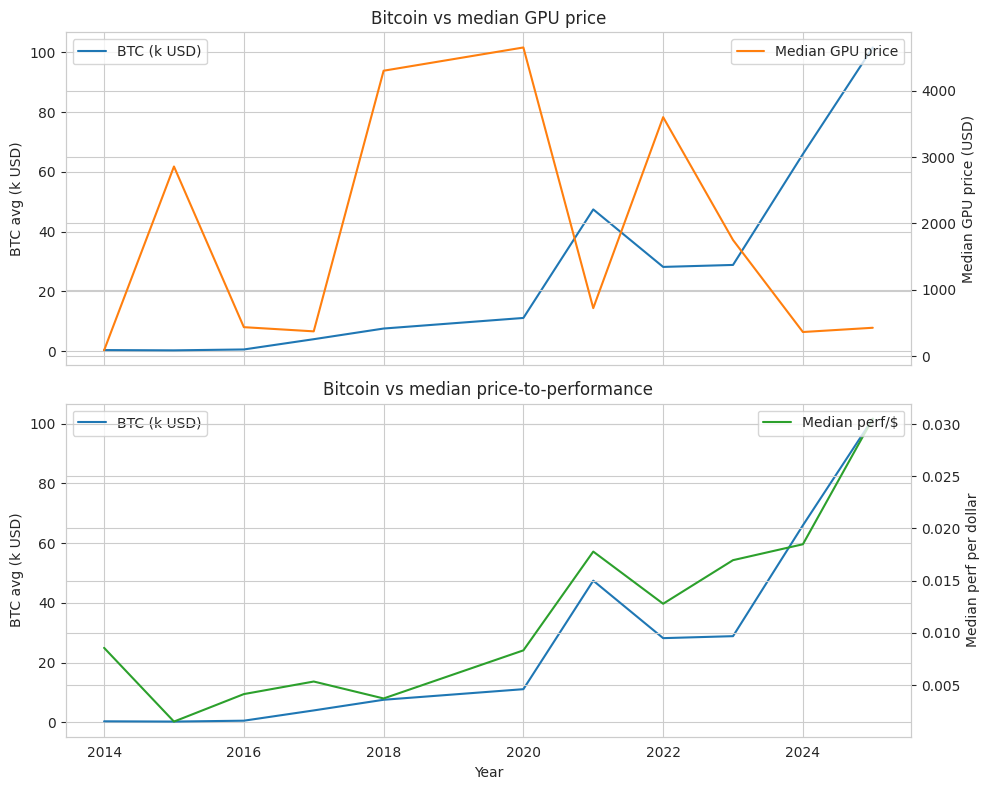

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax1.plot(df["year"], df["btc_avg_price"] / 1e3, label="BTC (k USD)", color="C0")
ax1.set_ylabel("BTC avg (k USD)")
ax1.legend(loc="upper left")
ax1_twin = ax1.twinx()
ax1_twin.plot(df["year"], df["median_gpu_price"], label="Median GPU price", color="C1")
ax1_twin.set_ylabel("Median GPU price (USD)")
ax1_twin.legend(loc="upper right")
ax1.set_title("Bitcoin vs median GPU price")

ax2.plot(df["year"], df["btc_avg_price"] / 1e3, label="BTC (k USD)", color="C0")
ax2.set_ylabel("BTC avg (k USD)")
ax2.legend(loc="upper left")
ax2_twin = ax2.twinx()
ax2_twin.plot(df["year"], df["median_perf_per_dollar"], label="Median perf/$", color="C2")
ax2_twin.set_ylabel("Median perf per dollar")
ax2_twin.legend(loc="upper right")
ax2.set_title("Bitcoin vs median price-to-performance")
ax2.set_xlabel("Year")
plt.tight_layout()
plt.show()

## Scatter: median GPU price vs BTC (with regression line)

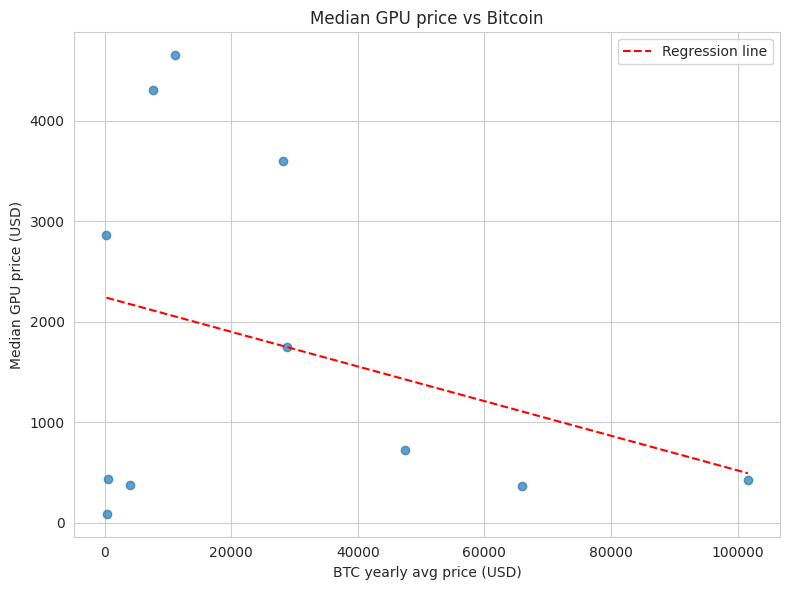

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["btc_avg_price"], df["median_gpu_price"], alpha=0.7)
z = np.polyfit(df["btc_avg_price"], df["median_gpu_price"], 1)
p = np.poly1d(z)
x_line = np.linspace(df["btc_avg_price"].min(), df["btc_avg_price"].max(), 100)
ax.plot(x_line, p(x_line), "r--", label="Regression line")
ax.set_xlabel("BTC yearly avg price (USD)")
ax.set_ylabel("Median GPU price (USD)")
ax.set_title("Median GPU price vs Bitcoin")
ax.legend()
plt.tight_layout()
plt.show()

## Supply chain vs GPU price

Yearly returns of the GPU supply chain (TSMC fab, NVIDIA, AMD, Micron) and median GPU price. When supply chain returns move with GPU price, it supports that the same demand/supply and macro factors affect both.

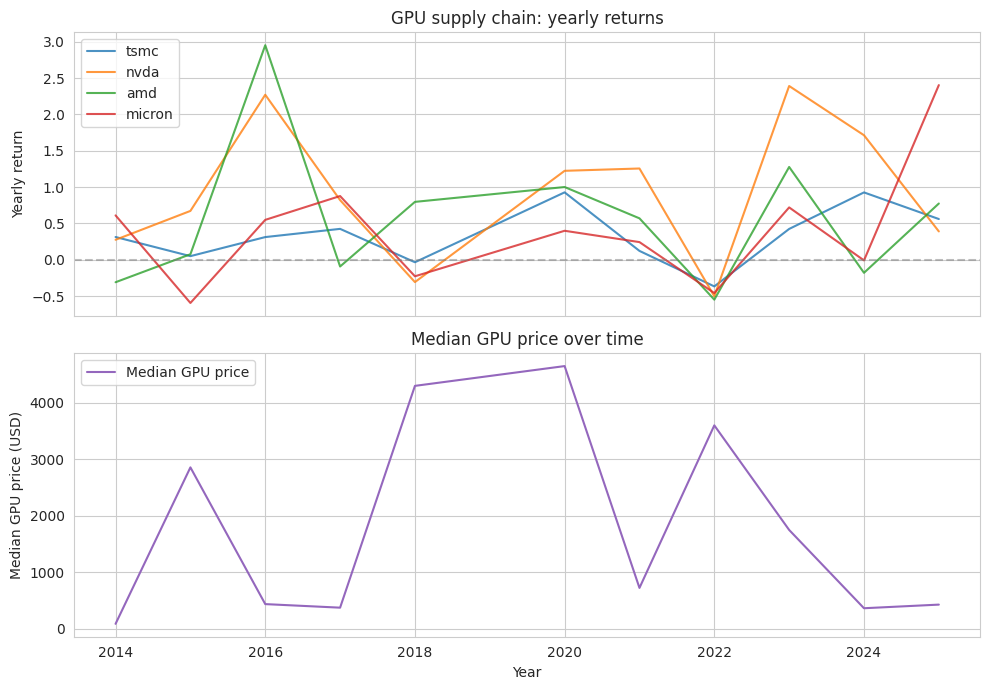

In [19]:
sc_cols = [c for c in ["tsmc_return", "nvda_return", "amd_return", "micron_return"] if c in df.columns]
if sc_cols:
    df_sc = df.dropna(subset=["median_gpu_price"] + sc_cols).sort_values("year")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    for c in sc_cols:
        ax1.plot(df_sc["year"], df_sc[c], label=c.replace("_return", ""), alpha=0.8)
    ax1.set_ylabel("Yearly return")
    ax1.legend(loc="upper left")
    ax1.set_title("GPU supply chain: yearly returns")
    ax1.axhline(0, color="gray", linestyle="--", alpha=0.5)
    ax2.plot(df_sc["year"], df_sc["median_gpu_price"], color="C4", label="Median GPU price")
    ax2.set_ylabel("Median GPU price (USD)")
    ax2.legend(loc="upper left")
    ax2.set_title("Median GPU price over time")
    ax2.set_xlabel("Year")
    plt.tight_layout()
    plt.show()
else:
    print("Supply chain columns not in merged data. Run EDA and correlation to build supply_chain_yearly.csv and merge.")

## Findings

- **BTC vs GPU price:** Time series and scatter show whether crypto and GPU prices move together; the regression line summarizes linear association.
- **Perf-per-dollar:** Improves over time as hardware gets cheaper per unit performance; comparison with BTC highlights different drivers (crypto vs gaming/AI).
- **Supply chain:** When present, fab and designer returns often correlate with GPU demand; divergences can reflect inventory or segment-specific shocks.